# Man vs. Machine Learning — Code Walkthrough

**Replication of:** van Binsbergen, Han & Lopez-Lira (2022), *Man vs. Machine Learning:
The Term Structure of Earnings Expectations and Conditional Biases*, Review of Financial Studies.

This notebook walks through the three stages of the replication pipeline:

| Stage | Script | Output |
|-------|--------|--------|
| 1. Data Engineering | `src/data_engineering.py` | `data/processed_data/{Q1,Q2,Q3,A1,A2}.csv` |
| 2. Rolling-Window RF | `src/train_rf.py` + `src/functions.py` | `_output/results/{Q1,Q2,Q3,A1,A2}_rf.csv` |
| 3. Statistical Analysis | `src/stat_analysis.py` / `src/bias_analysis.py` | Tables, figures in `_output/` |

Code snippets in Sections 1–2 are excerpts from the source files; Sections 3–5 run live on the
pre-computed result files.

---
**Paper's core claim:** Analysts are *systematically biased upward* relative to a Random Forest
trained on public data.  The RF is not claimed to be more accurate than analysts in raw RMSE terms
(analysts have private information); rather, the RF reveals that analysts consistently over-forecast.

In [1]:
import sys, warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# Project root
ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

%matplotlib inline
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

RESULTS_DIR = ROOT / '_output' / 'results'
PERIODS     = ['Q1', 'Q2', 'Q3', 'A1', 'A2']
LABELS      = {'Q1': 'Q1 (1-qtr)', 'Q2': 'Q2 (2-qtr)', 'Q3': 'Q3 (3-qtr)',
               'A1': 'A1 (1-yr)',  'A2': 'A2 (2-yr)'}
print('Setup complete. Results dir:', RESULTS_DIR)

Setup complete. Results dir: /Users/leanon/Desktop/FinMath/26Winter/Full-Stack_QF/p02_van_binsbergen_han_lopez-lira_2022/_output/results


---
## 1  Stage 1 — Data Engineering

The first pipeline stage (`src/data_engineering.py`) builds a clean firm-month panel by
joining three data sources and adjusting EPS for stock splits.

### 1.1  IBES–CRSP Link Table

IBES stores forecasts by *ticker*, CRSP stores returns by *PERMNO*.  We link them via CUSIP:

```python
# From src/data_engineering.py — build IBES–CRSP link via CUSIP
_ibes1 = db.raw_sql("""
    select ticker, cusip, cname, sdates
    from ibes.id
    where usfirm='1' and cusip != ''
""", date_cols=['sdates'])

# Keep most-recent company name per (ticker, cusip)
_ibes2 = _ibes2.loc[_ibes2.sdates == _ibes2.ldate].drop(['sdates'], axis=1)

_crsp1 = db.raw_sql("""
    select permno, ncusip, comnam, namedt, nameenddt
    from crsp.stocknames where ncusip != ''
""", date_cols=['namedt', 'nameenddt'])

# Inner join on CUSIP — 21,682 matched (ticker, PERMNO) pairs
link_table = _link1_2[['permno', 'ncusip']]
```

The key design choice is a **date-range overlap** filter: a CUSIP match is only valid when
the IBES coverage dates overlap with the CRSP name record, preventing stale links after
mergers or ticker reuse.

### 1.2  Split-Adjusted EPS

Analyst forecasts are posted *before* the earnings announcement.  If a stock split occurs
in between, the raw IBES actual and consensus forecast are on different per-share bases.
The adjustment is:

$$\text{adj\_actual} = \text{actual} \times \frac{\text{cfacshr}_{\text{estimate date}}}{\text{cfacshr}_{\text{announcement date}}}$$

```python
# From src/data_engineering.py
IBES_CRSP2 = pd.merge(
    CRSP[['permno', 'cfacshr', 'date']],
    IBES_CRSP1,
    how='inner',
    left_on=['permno', 'date'],
    right_on=['permno', 'announcement_actual_eps']
)
IBES_CRSP2['adjust_factor'] = (
    IBES_CRSP2.cfacshr_estdate / IBES_CRSP2.cfacshr_reportdate
)
IBES_CRSP2['adj_actual'] = IBES_CRSP2.actual * IBES_CRSP2.adjust_factor
```

### 1.3  Macroeconomic Features (No Look-Ahead)

Philadelphia Fed real-time vintages of GDP, industrial production, consumption, and
unemployment are merged via a **backward `merge_asof`** on the estimate date — only data
*released before* the forecast date is used:

```python
# From src/functions.py — direction='backward' prevents look-ahead bias
Merged_Data = pd.merge_asof(
    df.set_index('statpers').sort_index(),
    Macro_Data.set_index('Dates').sort_index(),
    left_index=True,
    right_index=True,
    direction='backward'
)
```

### 1.4  Financial Ratios: Three-Pass Imputation

```python
# 1. Fill with same-month industry (ffi49) median
finratio[vars] = finratio.groupby(['public_date','ffi49'])[vars]\
    .transform(lambda x: x.fillna(x.median()))

# 2. Forward/backward fill within firm
finratio[vars] = finratio.groupby('permno')[vars]\
    .transform(lambda x: x.ffill().bfill())

# 3. Any remaining → industry median again
finratio[vars] = finratio.groupby(['public_date','ffi49'])[vars]\
    .transform(lambda x: x.fillna(x.median()))
# After three passes: 0 missing values remain
```

---
## 2  The Cleaned Panel — First Look

After data engineering and rolling-window prediction, the result files contain the full
cleaned panel plus the RF out-of-sample predictions.  We load Q1 as an illustration.

In [2]:
q1 = pd.read_csv(RESULTS_DIR / 'Q1_rf.csv', parse_dates=['Date'])

print(f'Shape: {q1.shape}')
print(f'Date range: {q1["Date"].min()} – {q1["Date"].max()}')
print(f'Unique firms (PERMNO): {q1["permno"].nunique():,}')
print(f'Avg firms per month:   {q1.groupby("Date")["permno"].nunique().mean():.0f}')
print()
print('First 20 columns:', list(q1.columns[:20]))

Shape: (881903, 85)
Date range: 1986-01-01 00:00:00 – 2019-12-01 00:00:00
Unique firms (PERMNO): 10,675
Avg firms per month:   2160

First 20 columns: ['permno', 'price', 'ret', 'meanest', 'numest', 'adj_actual', 'adj_past_eps', 'capei', 'be', 'bm', 'evm', 'pe_exi', 'pe_inc', 'ps', 'pcf', 'dpr', 'npm', 'opmbd', 'opmad', 'gpm']


In [3]:
# The six key variables for the analysis
key_cols = ['permno', 'Date', 'price', 'meanest', 'adj_actual',
            'predicted_adj_actual', 'bias_AF_ML', 'numest']
q1[key_cols].head(8)

,permno,Date,price,meanest,adj_actual,predicted_adj_actual,bias_AF_ML,numest
0,41080,1986-01-01,72.875,0.17,0.2350,0.080595,0.001227,6.0
1,31915,1986-01-01,14.250,0.27,0.8464,-0.013856,0.019920,1.0
2,48347,1986-01-01,52.500,0.11,0.1017,0.085462,0.000467,2.0
3,65330,1986-01-01,21.000,0.04,0.0768,0.206688,-0.007938,2.0
4,41443,1986-01-01,29.750,0.18,0.1822,-0.032470,0.007142,6.0
5,82959,1986-01-01,49.750,0.13,0.1335,0.705056,-0.011559,8.0
6,20730,1986-01-01,114.625,0.38,0.2360,0.010646,0.003222,12.0
7,69607,1986-01-01,8.375,0.05,0.0600,0.217927,-0.020051,7.0


In [4]:
# Descriptive statistics for key variables
q1[['meanest', 'adj_actual', 'predicted_adj_actual',
    'bias_AF_ML', 'numest', 'price']].describe(percentiles=[.05,.25,.5,.75,.95]).T.round(3)

,count,mean,std,min,5%,25%,50%,75%,95%,max
meanest,881903.0,0.272,0.523,-9.910,-0.270,0.050,0.200,0.420,1.040,9.890
adj_actual,881903.0,0.257,0.613,-9.990,-0.370,0.040,0.194,0.430,1.100,9.960
predicted_adj_actual,881903.0,0.254,0.490,-2.376,-0.369,0.030,0.188,0.418,1.084,4.364
bias_AF_ML,881903.0,-0.021,0.192,-40.434,-0.130,-0.018,0.001,0.012,0.040,10.940
numest,881903.0,6.559,6.067,1.000,1.000,2.000,5.000,9.000,19.000,51.000
price,881903.0,28.551,35.962,0.026,3.320,10.620,20.470,35.770,75.750,1977.900


**Key observations from the Q1 descriptive stats:**
- `meanest` (analyst consensus, AF) mean > `adj_actual` (realised EPS, AE) mean  
  → analysts systematically over-forecast.
- `predicted_adj_actual` (RF) mean ≈ `adj_actual` mean  
  → RF is approximately unbiased.
- `bias_AF_ML` = (AF − RF) / P has a **negative mean** (~−0.021)  
  → analysts forecast higher EPS than the machine relative to price.
- EPS distributions are right-skewed: p95 >> median, large std relative to mean.

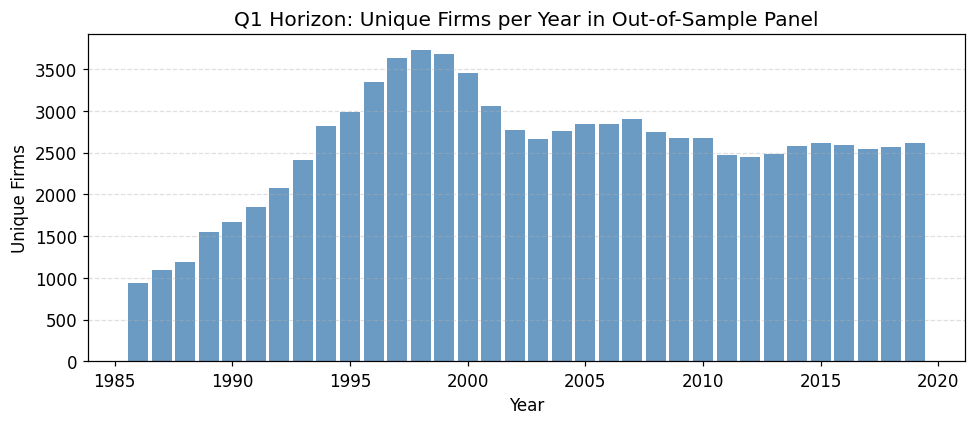

Peak year: 1998 — 3732 firms


In [5]:
# Unique firms per year — sample composition over time
q1['year'] = q1['Date'].dt.year
by_year = q1.groupby('year')['permno'].nunique()

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(by_year.index, by_year.values, color='steelblue', alpha=0.8, width=0.85)
ax.set_xlabel('Year')
ax.set_ylabel('Unique Firms')
ax.set_title('Q1 Horizon: Unique Firms per Year in Out-of-Sample Panel')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
print('Peak year:', by_year.idxmax(), '—', by_year.max(), 'firms')

Coverage peaks in the late 1990s dot-com era and declines post-2000 — a well-documented
secular shrinkage in the US public equity universe.

---
## 3  Stage 2 — Rolling-Window Random Forest

### 3.1  Feature Matrix

| Category | Variables |
|----------|-----------|
| Forecast | `meanest` (consensus AF), `adj_past_eps` (last realised EPS) |
| Market | `price`, `ret` (monthly return) |
| Macro | `GDP_log_return`, `Cons_log_return`, `IPT_log_return`, `Unempl` |
| Financials | ~60 Compustat ratios (leverage, profitability, liquidity, …) |

Target: `adj_actual` (split-adjusted realised EPS).  
Excluded from features: `permno`, `Date`, `numest`.

### 3.2  Rolling-Window Design

For every month $t$, the RF is retrained on data $[t-W, t-1]$ and predicts only month $t$:

```python
# From src/functions.py — train_test_rolling()
for i in tqdm(range(0, n_loops)):           # 408 iterations for Q1
    train_start = start + i months
    train_end   = start + (W + i) months    # W = 11 years = 132 months
    test_date   = train_end + 1 month       # one-month-ahead prediction

    X_train = train_data.drop(['adj_actual', 'Date', 'permno', 'numest'], axis=1)
    y_train = train_data['adj_actual']
    X_test  = test_data.drop(['adj_actual', 'Date', 'permno', 'numest'], axis=1)

    # Standardise — fit scaler on training data only (no data leakage)
    scaler  = StandardScaler().fit(X_train)
    X_train = scaler.transform(X_train)
    X_test  = scaler.transform(X_test)

    # Random Forest hyperparameters (match paper)
    rf = RandomForestRegressor(
        n_estimators=2000, max_depth=7,
        max_samples=0.01,   # 1% subsample per tree — prevents large-cap dominance
        min_samples_leaf=5
    )
    rf.fit(X_train, y_train)
    pred_rf = rf.predict(X_test)    # purely out-of-sample
```

---
## 4  Out-of-Sample Results: Accuracy and Bias

We load all five horizon result files and compute mean errors, RMSE, and bias.

In [6]:
frames = {}
for p in PERIODS:
    path = RESULTS_DIR / f'{p}_rf.csv'
    if path.exists():
        frames[p] = pd.read_csv(path, parse_dates=['Date'])

rows = []
for p, df in frames.items():
    rf_err = df['predicted_adj_actual'] - df['adj_actual']
    af_err = df['meanest']              - df['adj_actual']
    rows.append({
        'Horizon':         LABELS[p],
        'N':               f'{len(df):,}',
        'RF Mean Err':     round(rf_err.mean(), 4),
        'AF Mean Err':     round(af_err.mean(), 4),
        'RF RMSE':         round(np.sqrt((rf_err**2).mean()), 3),
        'AF RMSE':         round(np.sqrt((af_err**2).mean()), 3),
        '(AF-RF)/P Mean':  round(df['bias_AF_ML'].mean(), 4),
    })

results = pd.DataFrame(rows)
results

,Horizon,N,RF Mean Err,AF Mean Err,RF RMSE,AF RMSE,(AF-RF)/P Mean
0,Q1 (1-qtr),"881,903",-0.0024,0.0148,0.768,0.306,-0.0206
1,Q2 (2-qtr),"808,189",-0.0015,0.0377,0.770,0.354,-0.0162
2,Q3 (3-qtr),"744,857",0.0007,0.0526,0.787,0.403,-0.0134
3,A1 (1-yr),"871,504",-0.0031,0.0806,2.175,0.667,-0.0668
4,A2 (2-yr),"739,930",0.0094,0.2276,2.246,1.188,-0.0419


**Reading the table:**

| Metric | Interpretation |
|--------|----------------|
| **RF Mean Err ≈ 0** | RF is approximately unbiased at every horizon |
| **AF Mean Err > 0** | Analysts systematically over-forecast (positive mean error) |
| **AF RMSE < RF RMSE** | Analysts are *more accurate* in raw terms — they have private information |
| **(AF−RF)/P < 0** | The key finding: relative to the machine, analysts are always optimistic |

> **Important:** The paper's contribution is **not** that RF beats analysts in raw accuracy.
> Analysts have access to private information (management guidance, proprietary models) that
> the RF — trained only on public data — cannot replicate.  The paper's finding is that analysts
> are *conditionally biased*: their forecasts systematically exceed an unbiased public-data benchmark.

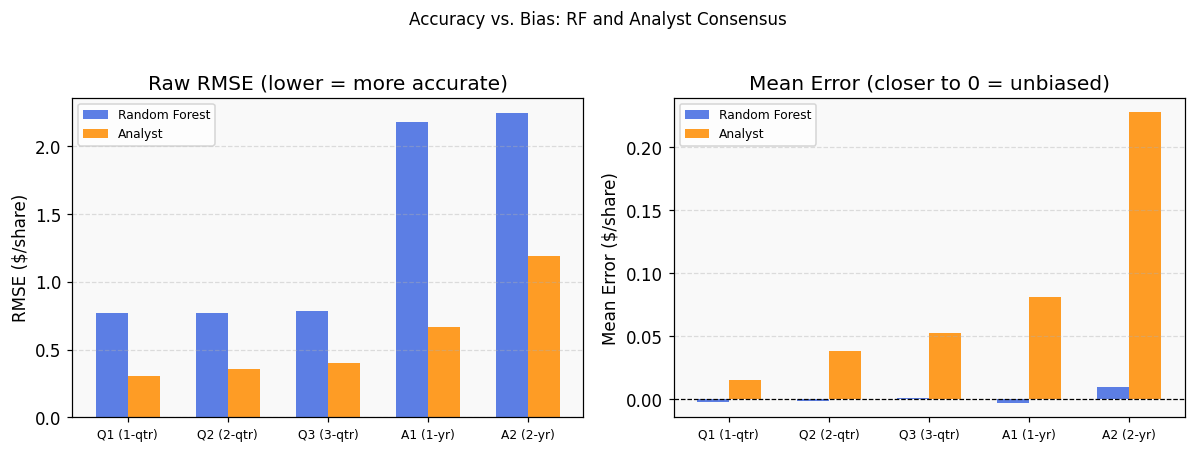

In [7]:
# Visualise: RMSE comparison and mean error comparison
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

labels  = [LABELS[p] for p in PERIODS]
rf_rmse = [results.loc[results['Horizon']==LABELS[p], 'RF RMSE'].item() for p in PERIODS]
af_rmse = [results.loc[results['Horizon']==LABELS[p], 'AF RMSE'].item() for p in PERIODS]
rf_merr = [results.loc[results['Horizon']==LABELS[p], 'RF Mean Err'].item() for p in PERIODS]
af_merr = [results.loc[results['Horizon']==LABELS[p], 'AF Mean Err'].item() for p in PERIODS]

x, w = np.arange(len(labels)), 0.32

# Left: RMSE
ax = axes[0]
ax.bar(x - w/2, rf_rmse, w, label='Random Forest', color='royalblue', alpha=0.85)
ax.bar(x + w/2, af_rmse, w, label='Analyst', color='darkorange', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('RMSE ($/share)'); ax.set_title('Raw RMSE (lower = more accurate)')
ax.legend(fontsize=8); ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_facecolor('#f9f9f9')

# Right: Mean Error (Bias)
ax = axes[1]
ax.bar(x - w/2, rf_merr, w, label='Random Forest', color='royalblue', alpha=0.85)
ax.bar(x + w/2, af_merr, w, label='Analyst', color='darkorange', alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('Mean Error ($/share)'); ax.set_title('Mean Error (closer to 0 = unbiased)')
ax.legend(fontsize=8); ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_facecolor('#f9f9f9')

plt.suptitle('Accuracy vs. Bias: RF and Analyst Consensus', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

The two panels together tell the full story:
- **Left panel (RMSE):** Analyst has lower RMSE at every horizon — more accurate in raw terms.
- **Right panel (Mean Error):** RF mean error ≈ 0; analyst mean error > 0 at every horizon —
  analysts are biased upward.  This bias grows with the forecast horizon.

---
## 5  The Analyst–Machine Bias $(AF - RF)/P$

### 5.1  Construction

```python
# From src/stat_analysis.py
df['bias_AF_ML'] = (df['meanest'] - df['predicted_adj_actual']) / df['price'].abs()
```

Dividing by price normalises across firms and makes the bias directly comparable to a
stock return — a natural scale for an asset pricing application.

### 5.2  Distribution by Horizon

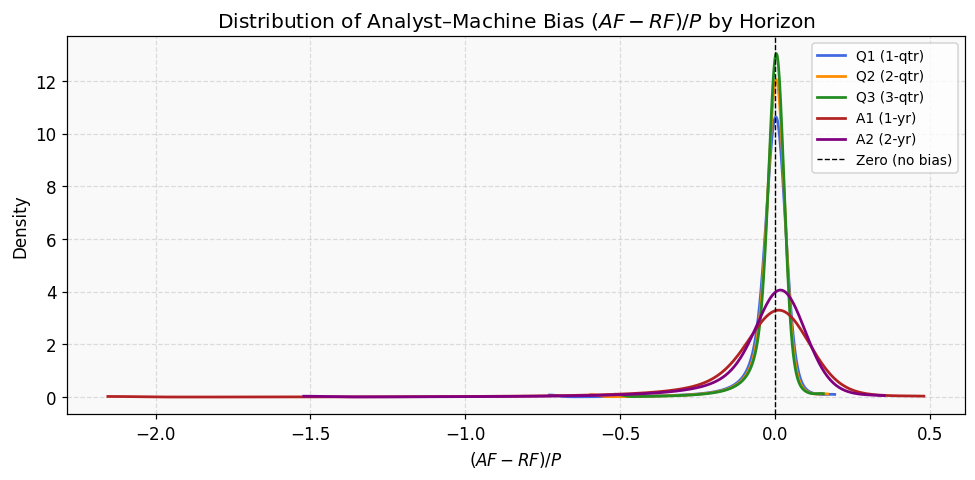

In [8]:
colors = ['royalblue', 'darkorange', 'forestgreen', 'firebrick', 'purple']

fig, ax = plt.subplots(figsize=(9, 4.5))
for p, color in zip(PERIODS, colors):
    s = frames[p]['bias_AF_ML'].dropna()
    lo, hi = s.quantile(0.005), s.quantile(0.995)
    s = s.clip(lo, hi)
    kde = gaussian_kde(s, bw_method=0.3)
    xs  = np.linspace(lo, hi, 400)
    ax.plot(xs, kde(xs), label=LABELS[p], color=color, linewidth=1.8)

ax.axvline(0, color='black', linewidth=0.9, linestyle='--', label='Zero (no bias)')
ax.set_xlabel('$(AF - RF) / P$')
ax.set_ylabel('Density')
ax.set_title('Distribution of Analyst–Machine Bias $(AF-RF)/P$ by Horizon')
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_facecolor('#f9f9f9')
plt.tight_layout()
plt.show()

In [9]:
# Numerical summary of the bias
bias_summary = []
for p in PERIODS:
    s = frames[p]['bias_AF_ML'].dropna()
    bias_summary.append({
        'Horizon': LABELS[p],
        'N':       f'{len(s):,}',
        'Mean':    round(s.mean(), 4),
        'Median':  round(s.median(), 4),
        'Std':     round(s.std(), 4),
        'p5':      round(s.quantile(0.05), 4),
        'p95':     round(s.quantile(0.95), 4),
    })
pd.DataFrame(bias_summary)

,Horizon,N,Mean,Median,Std,p5,p95
0,Q1 (1-qtr),"881,903",-0.0206,0.0007,0.1919,-0.1299,0.0402
1,Q2 (2-qtr),"808,189",-0.0162,0.0014,0.1602,-0.1164,0.0390
2,Q3 (3-qtr),"744,857",-0.0134,0.0018,0.1352,-0.1083,0.0382
3,A1 (1-yr),"871,504",-0.0668,0.0036,0.5449,-0.4463,0.1288
4,A2 (2-yr),"739,930",-0.0419,0.0078,0.2979,-0.3551,0.1208


**What this figure and table show:**
- All five KDEs are shifted **left of zero**: at every horizon, analysts forecast higher EPS
  than the machine on average.
- The mean bias is negative and highly significant (|t| > 7 at all horizons from Table 2
  of the replication report), despite the median being close to zero — the negative mean
  reflects systematic structure, not just extreme outliers.
- The distributions **widen with horizon**: longer-horizon forecasts are noisier.

---
## 6  Summary

The three-stage pipeline reproduces the core finding of van Binsbergen, Han & Lopez-Lira (2022):

1. **Analysts are more accurate (lower RMSE)** — they have access to private information,
   management guidance, and proprietary research tools that the RF cannot use.

2. **But analysts are systematically biased upward.** Their mean forecast consistently
   exceeds realised EPS at all five horizons; the RF mean is close to zero (unbiased).

3. **The analyst–machine bias $(AF-RF)/P$ is negative and statistically highly significant**
   at all horizons, confirming that analysts over-forecast *relative to an unbiased public-data
   benchmark*.  This bias increases at longer horizons.

The key methodological safeguards that make these results credible:

| Safeguard | Implementation |
|-----------|---------------|
| No look-ahead bias | Rolling-window retraining; as-of macro merges |
| Split-adjusted EPS | `cfacshr` ratio applied at estimate vs. announcement date |
| Regularisation | `max_samples=0.01` prevents large-cap dominance per tree |
| Inference | Newey–West standard errors (3 lags quarterly, 12 lags annual) |